# 任务4：6+rg 模型贝叶斯优化

流程：

1. 以原论文6特征模型及其参数作为固定基准；
2. 对“原始6特征 + rg”模型使用 Optuna-TPE 进行超参数优化；
3. 调参只使用固定划分中728条训练样本，并在训练集内部做5折交叉验证；
4. 获得最优参数后，在240组相同随机划分上重新评价；
5. 比较原始6特征论文参数、6+rg论文参数、6+rg优化参数三组结果。


In [1]:
from pathlib import Path
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "缺少 optuna。请先在 PowerShell 中运行：\n"
        "conda activate tpaml\n"
        "python -m pip install optuna"
    ) from exc

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_FILE = Path('model_input_6_plus_spatial_856.csv')
RESULT_DIR = Path('task4_rg_bayesian_optimization')
RESULT_DIR.mkdir(exist_ok=True)

N_TRIALS = 50
OPTIMIZATION_SPLIT_SEED = 0
CV_SPLITS = 5
N_RUNS = 240
SEEDS = list(range(N_RUNS))
TRAIN_SIZE = 728
TEST_SIZE = 128
LN10 = np.log(10)


g:\Anaconda\envs\tpaml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f'找不到数据文件：{DATA_FILE.resolve()}\n'
        '请把 model_input_6_plus_spatial_856.csv 与本 Notebook 放在同一文件夹。'
    )

df = pd.read_csv(DATA_FILE)
print('数据形状：', df.shape)
print('缺失值总数：', int(df.isna().sum().sum()))
display(df.head())


数据形状： (856, 21)
缺失值总数： 0


,model_row,Old_index_1,smiles,canonical_smiles,doi,compoundId,Conju-Max-Distance,Wavelength (Exp nm),ET(30) (Solvent),PEOE-Charge-Max,...,Atomic-MR-Max,rg,asphericity,eccentricity,num_chiral_centers,num_cis_trans,rg_mw_ratio,molecular_weight,rigid_bond_ratio,values_ln
0,0,1,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2a,10,750,37.4,0.285785,...,26.486,4.209492,0.242658,0.915303,0,0,0.009736,432.376,0.135135,3.871201
1,1,2,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.036,2b,11,760,37.4,0.285785,...,26.486,4.353599,0.268298,0.926502,0,0,0.009667,450.366,0.131579,3.828641
2,2,3,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.037,2c,11,750,37.4,0.285785,...,26.486,4.533366,0.269609,0.927593,0,0,0.009711,466.821,0.131579,4.477337
3,3,5,CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1)[N+...,CAN:CCN(CC)c1ccc2c(c1)O[B-](c1ccccc1)(c1ccccc1...,10.1016/j.jorganchem.2013.12.039,2e,11,750,37.4,0.285785,...,26.486,4.512181,0.271346,0.927907,0,0,0.009758,462.402,0.128205,3.713572
4,4,6,CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]2(c2...,CAN:CCN(CC)c1ccc([N+]2=Cc3ccc(N(CC)CC)cc3O[B-]...,10.1016/j.jorganchem.2013.12.040,2f,11,740,37.4,0.285785,...,26.486,4.850971,0.365411,0.955132,0,0,0.009635,503.499,0.119048,3.988984


In [3]:
BASE_FEATURES = [
    'Conju-Max-Distance',
    'Wavelength (Exp nm)',
    'ET(30) (Solvent)',
    'PEOE-Charge-Max',
    'Atomic-LogP-Min',
    'Atomic-MR-Max',
]
RG_FEATURES = BASE_FEATURES + ['rg']
TARGET = 'values_ln'

required = RG_FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f'缺少列：{missing}')

X_base = df[BASE_FEATURES].astype(float)
X_rg = df[RG_FEATURES].astype(float)
y = df[TARGET].astype(float)

print('基准模型特征数：', X_base.shape[1])
print('6+rg模型特征数：', X_rg.shape[1])


基准模型特征数： 6
6+rg模型特征数： 7


In [4]:
PAPER_PARAMS = dict(
    n_estimators=150,
    learning_rate=0.025,
    max_depth=13,
    verbosity=0,
    booster='gbtree',
    reg_alpha=np.exp(-6.788644799030888),
    reg_lambda=np.exp(-7.450413274554533),
    gamma=np.exp(-5.374463422208394),
    subsample=0.5,
    objective='reg:squarederror',
    n_jobs=-1,
)

indices = np.arange(len(df))
opt_train_idx, opt_holdout_idx = train_test_split(
    indices,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    random_state=OPTIMIZATION_SPLIT_SEED,
    shuffle=True,
)

X_opt = X_rg.iloc[opt_train_idx]
y_opt = y.iloc[opt_train_idx]

cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=OPTIMIZATION_SPLIT_SEED)
print('用于贝叶斯优化的训练样本：', len(X_opt))
print('保留但不参与调参的外部测试样本：', len(opt_holdout_idx))


用于贝叶斯优化的训练样本： 728
保留但不参与调参的外部测试样本： 128


In [5]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 15.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 20.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-6, 5.0, log=True),
        'objective': 'reg:squarederror',
        'booster': 'gbtree',
        'tree_method': 'hist',
        'n_jobs': -1,
        'verbosity': 0,
        'random_state': OPTIMIZATION_SPLIT_SEED,
    }

    model = XGBRegressor(**params)
    scores = cross_val_score(
        model,
        X_opt,
        y_opt,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=OPTIMIZATION_SPLIT_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('最优5折CV MSE（ln尺度）：', study.best_value)
print('最优参数：')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')


Best trial: 13. Best value: 1.16578: 100%|██████████| 50/50 [01:56<00:00,  2.33s/it]

最优5折CV MSE（ln尺度）： 1.1657824294330008
最优参数：
  n_estimators: 517
  learning_rate: 0.03056615251594733
  max_depth: 8
  min_child_weight: 1.2464089098341038
  subsample: 0.6282410960594094
  colsample_bytree: 0.5106527077425275
  reg_alpha: 0.00014211983296353136
  reg_lambda: 0.00012810216725359753
  gamma: 1.0641499535917179e-06


In [6]:
OPTIMIZED_PARAMS = {
    **study.best_params,
    'objective': 'reg:squarederror',
    'booster': 'gbtree',
    'tree_method': 'hist',
    'n_jobs': -1,
    'verbosity': 0,
}

trials_df = study.trials_dataframe()
trials_df.to_csv(
    RESULT_DIR / 'optuna_trials.csv',
    index=False,
    encoding='utf-8-sig',
)

with open(RESULT_DIR / 'best_params_6_plus_rg.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'best_cv_mse_ln': study.best_value,
            'best_params': OPTIMIZED_PARAMS,
            'n_trials': N_TRIALS,
            'optimization_split_seed': OPTIMIZATION_SPLIT_SEED,
            'cv_splits': CV_SPLITS,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )


In [7]:
def evaluate_240(model_name, X, params):
    rows = []
    indices = np.arange(len(df))

    for seed in SEEDS:
        train_idx, test_idx = train_test_split(
            indices,
            train_size=TRAIN_SIZE,
            test_size=TEST_SIZE,
            random_state=seed,
            shuffle=True,
        )

        model = XGBRegressor(random_state=seed, **params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx])

        mse_ln = mean_squared_error(y.iloc[test_idx], pred)
        mae_ln = mean_absolute_error(y.iloc[test_idx], pred)
        r2 = r2_score(y.iloc[test_idx], pred)

        rows.append({
            'model': model_name,
            'seed': seed,
            'MSE_ln': mse_ln,
            'MAE_ln': mae_ln,
            'MSE_lg': mse_ln / LN10**2,
            'MAE_lg': mae_ln / LN10,
            'R2': r2,
        })

    return pd.DataFrame(rows)

baseline_results = evaluate_240('6特征_论文参数', X_base, PAPER_PARAMS)
rg_paper_results = evaluate_240('6+rg_论文参数', X_rg, PAPER_PARAMS)
rg_opt_results = evaluate_240('6+rg_优化参数', X_rg, OPTIMIZED_PARAMS)

all_results = pd.concat(
    [baseline_results, rg_paper_results, rg_opt_results],
    ignore_index=True,
)
all_results.to_csv(
    RESULT_DIR / 'three_models_240_runs_metrics.csv',
    index=False,
    encoding='utf-8-sig',
)
print('三组模型的240次评价完成。')


三组模型的240次评价完成。


In [8]:
summary = (
    all_results.groupby('model')[['MSE_lg', 'MAE_lg', 'R2']]
    .agg(['mean', 'std'])
)
display(summary.round(4))
summary.to_csv(
    RESULT_DIR / 'three_models_summary.csv',
    encoding='utf-8-sig',
)

base = baseline_results.set_index('seed')
rg_paper = rg_paper_results.set_index('seed')
rg_opt = rg_opt_results.set_index('seed')

comparison = pd.DataFrame({
    'model': ['6特征_论文参数', '6+rg_论文参数', '6+rg_优化参数'],
    'MSE_lg_mean': [
        base['MSE_lg'].mean(),
        rg_paper['MSE_lg'].mean(),
        rg_opt['MSE_lg'].mean(),
    ],
    'MAE_lg_mean': [
        base['MAE_lg'].mean(),
        rg_paper['MAE_lg'].mean(),
        rg_opt['MAE_lg'].mean(),
    ],
    'R2_mean': [
        base['R2'].mean(),
        rg_paper['R2'].mean(),
        rg_opt['R2'].mean(),
    ],
    'R2优于6特征基准的次数': [
        0,
        int((rg_paper['R2'] > base['R2']).sum()),
        int((rg_opt['R2'] > base['R2']).sum()),
    ],
})
display(comparison.round(4))
comparison.to_csv(
    RESULT_DIR / 'comparison_with_baseline.csv',
    index=False,
    encoding='utf-8-sig',
)


MSE_lg          MAE_lg              R2        
             mean     std    mean     std    mean     std
model                                                    
6+rg_优化参数  0.2077  0.0313  0.3408  0.0246  0.6008  0.0582
6+rg_论文参数  0.2264  0.0339  0.3583  0.0258  0.5647  0.0647
6特征_论文参数   0.2148  0.0325  0.3464  0.0250  0.5868  0.0629

,model,MSE_lg_mean,MAE_lg_mean,R2_mean,R2优于6特征基准的次数
0,6特征_论文参数,0.2148,0.3464,0.5868,0
1,6+rg_论文参数,0.2264,0.3583,0.5647,47
2,6+rg_优化参数,0.2077,0.3408,0.6008,149


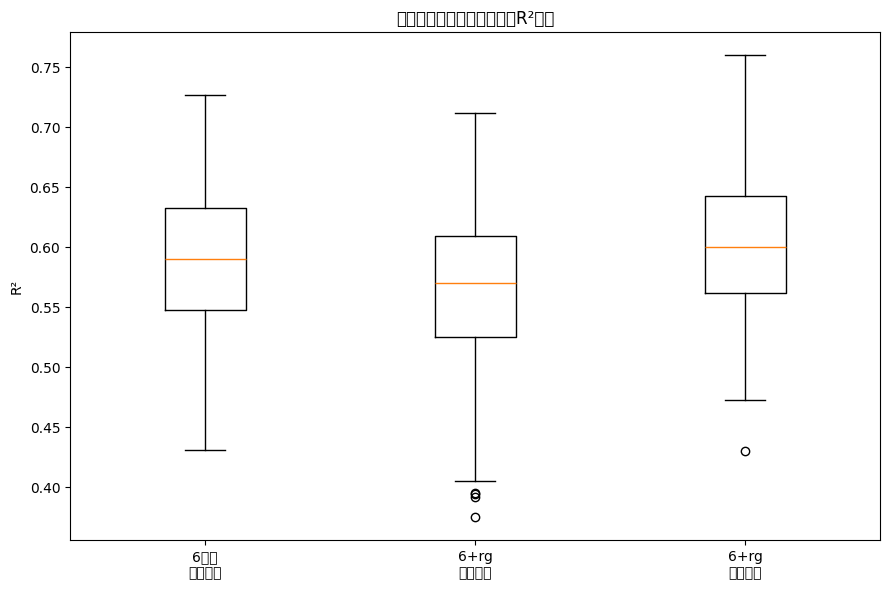

In [9]:
order = ['6特征_论文参数', '6+rg_论文参数', '6+rg_优化参数']
plot_data = [
    all_results.loc[all_results['model'] == name, 'R2']
    for name in order
]

plt.figure(figsize=(9, 6))
plt.boxplot(plot_data, labels=['6特征\n论文参数', '6+rg\n论文参数', '6+rg\n优化参数'])
plt.ylabel('R²')
plt.title('贝叶斯优化前后三组模型的R²分布')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'R2_before_after_optimization.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
final_model = XGBRegressor(random_state=0, **OPTIMIZED_PARAMS)
final_model.fit(X_rg, y)
joblib.dump(
    final_model,
    RESULT_DIR / 'xgboost_6_plus_rg_optimized_full_model.joblib',
)

print('最优参数和结果已保存到：', RESULT_DIR.resolve())


最优参数和结果已保存到： C:\Users\6\Desktop\SJTU\MI Chemistry\4\tpaml_unified_output\task4_rg_bayesian_optimization
